# Extra Analysis — Cost-Accuracy Trade-off & Retrieval Quality Impact

Two supplementary analyses:
1. **Cost-Accuracy Trade-off** — EM per token (normalised efficiency)
2. **Retrieval Quality Impact** — does finding the gold passage actually lead to correct answers?

In [1]:
import json
import os
import sys

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, os.path.join(os.getcwd(), ".."))
from src.evaluation.metrics import exact_match, token_f1

sns.set_theme(style="whitegrid", font_scale=1.15)
plt.rcParams.update({"figure.dpi": 130,
                     "axes.spines.top": False,
                     "axes.spines.right": False})

PALETTE = {"naive_rag": "#4C72B0", "iterative_rag": "#55A868", "agentic_rag": "#C44E52"}
LABELS  = {"naive_rag": "Naive RAG", "iterative_rag": "Iterative RAG", "agentic_rag": "Agentic RAG"}
SYSTEMS = ["naive_rag", "iterative_rag", "agentic_rag"]
RESULTS_DIR = "../results"

# ---------- load & build dataframe ----------
def to_df(results, sys_name):
    rows = []
    for r in results:
        pred  = r.get("predicted_answer", "")
        golds = r.get("all_answers") or [r.get("gold_answer", "")]
        rows.append({
            "system":            sys_name,
            "id":                r["id"],
            "dataset":           r["dataset"],
            "n_hops":            r["n_hops"],
            "question":          r["question"],
            "gold_answer":       r["gold_answer"],
            "predicted_answer":  pred,
            "em":                exact_match(pred, golds),
            "f1":                token_f1(pred, golds),
            "tokens_total":      r.get("tokens_total", 0),
            "latency_s":         r.get("latency_s", 0.0),
            "retrieval_success": int(any(p["is_gold"]
                                         for p in r.get("retrieved_passages", []))),
        })
    return pd.DataFrame(rows)

dfs = {}
for s in SYSTEMS:
    with open(os.path.join(RESULTS_DIR, f"{s}.json")) as f:
        dfs[s] = to_df(json.load(f), s)
    print(f"{LABELS[s]:20s}: {len(dfs[s]):,} records")

df = pd.concat(dfs.values(), ignore_index=True)
print(f"\nCombined: {df.shape}")

Naive RAG           : 2,000 records
Iterative RAG       : 2,000 records
Agentic RAG         : 2,000 records

Combined: (6000, 12)


---
## Analysis 1 — Cost-Accuracy Trade-off

In [2]:
# Summary stats per system
summary = pd.DataFrame({
    s: {
        "EM (%)": dfs[s]["em"].mean() * 100,
        "Token F1 (%)": dfs[s]["f1"].mean() * 100,
        "Avg Tokens": dfs[s]["tokens_total"].mean(),
        "EM per 1k Tokens": dfs[s]["em"].mean() * 100 / (dfs[s]["tokens_total"].mean() / 1000),
    }
    for s in SYSTEMS
}).T
summary.index = [LABELS[s] for s in SYSTEMS]
summary.round(2)

,EM (%),Token F1 (%),Avg Tokens,EM per 1k Tokens
Naive RAG,33.30,43.96,454.49,73.27
Iterative RAG,40.20,52.19,984.66,40.83
Agentic RAG,46.35,60.20,6465.04,7.17


/var/folders/k4/1_x_10b51qz8h3snzx_ytj5r0000gn/T/ipykernel_13416/400962884.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([LABELS[s] for s in SYSTEMS], rotation=10, ha="right")


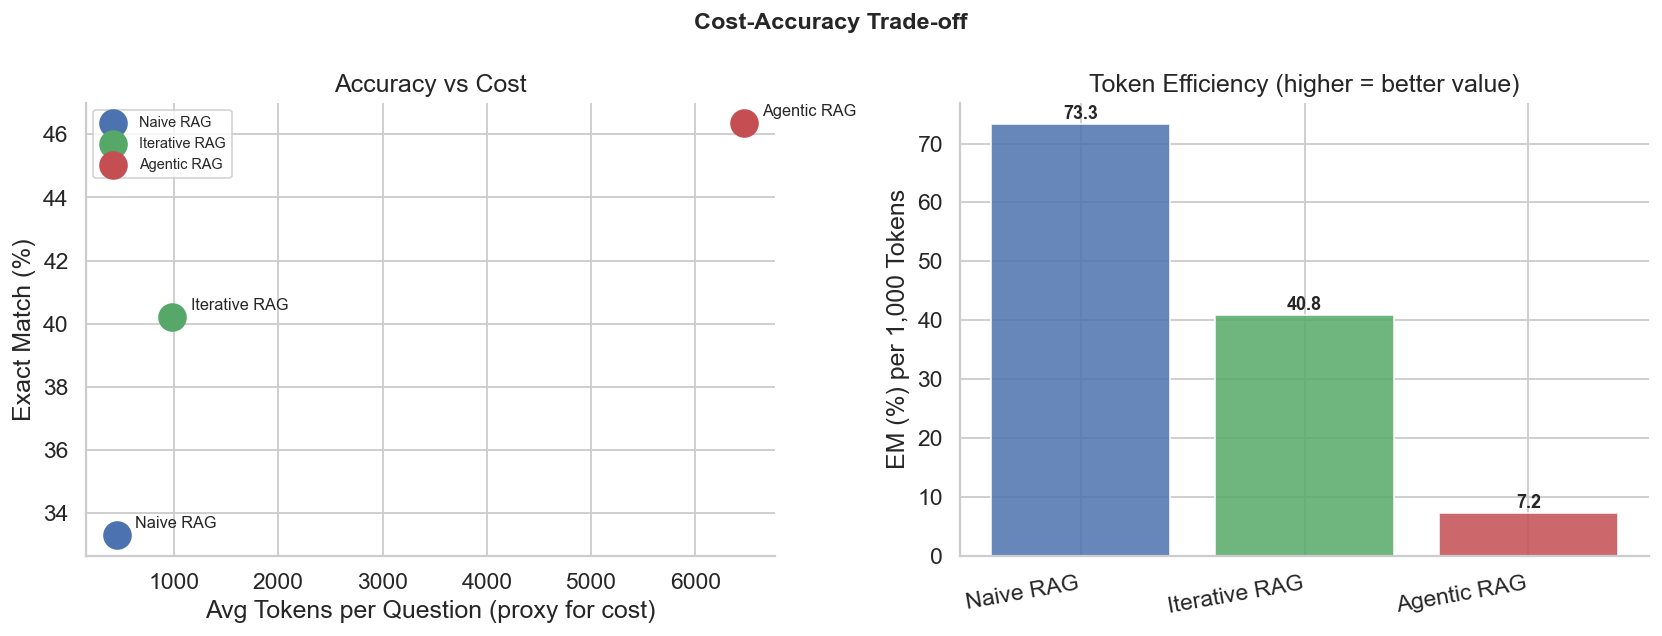

Saved → results/figures/cost_accuracy_tradeoff.png


In [3]:
# ── Figure 1a: Accuracy vs Token Cost (scatter) ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: scatter — each point = one system, x=tokens, y=EM
ax = axes[0]
for s in SYSTEMS:
    em  = dfs[s]["em"].mean() * 100
    tok = dfs[s]["tokens_total"].mean()
    ax.scatter(tok, em, s=220, color=PALETTE[s], zorder=3, label=LABELS[s])
    ax.annotate(LABELS[s], xy=(tok, em), xytext=(10, 4),
                textcoords="offset points", fontsize=9)

ax.set_xlabel("Avg Tokens per Question (proxy for cost)")
ax.set_ylabel("Exact Match (%)")
ax.set_title("Accuracy vs Cost")
ax.legend(fontsize=8)

# Right: EM per 1000 tokens (normalised efficiency)
ax = axes[1]
eff_vals = [
    dfs[s]["em"].mean() * 100 / (dfs[s]["tokens_total"].mean() / 1000)
    for s in SYSTEMS
]
bars = ax.bar([LABELS[s] for s in SYSTEMS], eff_vals,
              color=[PALETTE[s] for s in SYSTEMS], alpha=0.85)
for bar, v in zip(bars, eff_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{v:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("EM (%) per 1,000 Tokens")
ax.set_title("Token Efficiency (higher = better value)")
ax.set_xticklabels([LABELS[s] for s in SYSTEMS], rotation=10, ha="right")

fig.suptitle("Cost-Accuracy Trade-off", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/figures/cost_accuracy_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/figures/cost_accuracy_tradeoff.png")

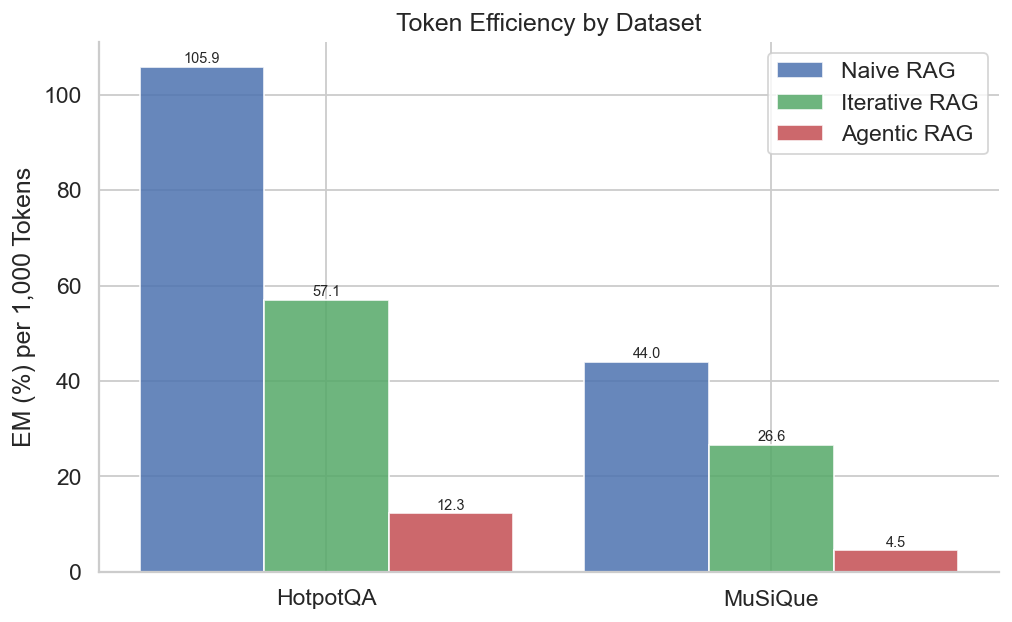

Saved → results/figures/token_efficiency_by_dataset.png


In [4]:
# ── Figure 1b: EM per 1k tokens broken down by dataset ───────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
datasets   = ["hotpotqa", "musique"]
ds_labels  = ["HotpotQA", "MuSiQue"]
x = np.arange(len(datasets))
width = 0.28

for i, s in enumerate(SYSTEMS):
    vals = [
        dfs[s][dfs[s].dataset == ds]["em"].mean() * 100
        / (dfs[s][dfs[s].dataset == ds]["tokens_total"].mean() / 1000)
        for ds in datasets
    ]
    bars = ax.bar(x + i * width, vals, width,
                  label=LABELS[s], color=PALETTE[s], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
                f"{v:.1f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(ds_labels)
ax.set_ylabel("EM (%) per 1,000 Tokens")
ax.set_title("Token Efficiency by Dataset")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/token_efficiency_by_dataset.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/figures/token_efficiency_by_dataset.png")

---
## Analysis 2 — Retrieval Quality Impact

Split each system's questions into two groups:
- **Gold Retrieved**: at least one gold passage was found  
- **Gold Missed**: no gold passage was found  

Then compare EM to answer: *does finding the right passage actually lead to the right answer?*

In [5]:
# ── Table: EM when gold retrieved vs missed ───────────────────────────────────
rows = []
for s in SYSTEMS:
    sub = dfs[s]
    hit  = sub[sub.retrieval_success == 1]
    miss = sub[sub.retrieval_success == 0]
    rows.append({
        "System": LABELS[s],
        "Gold Retrieved — n": len(hit),
        "Gold Retrieved — EM": f"{hit['em'].mean()*100:.1f}%",
        "Gold Missed — n": len(miss),
        "Gold Missed — EM": f"{miss['em'].mean()*100:.1f}%" if len(miss) > 0 else "—",
        "EM Gap": f"{(hit['em'].mean() - miss['em'].mean())*100:.1f}pp" if len(miss) > 0 else "—",
    })

pd.DataFrame(rows).set_index("System")

,Gold Retrieved — n,Gold Retrieved — EM,Gold Missed — n,Gold Missed — EM,EM Gap
System,,,,,
Naive RAG,1905,34.7%,95,5.3%,29.4pp
Iterative RAG,1938,41.3%,62,4.8%,36.5pp
Agentic RAG,1982,46.6%,18,22.2%,24.3pp


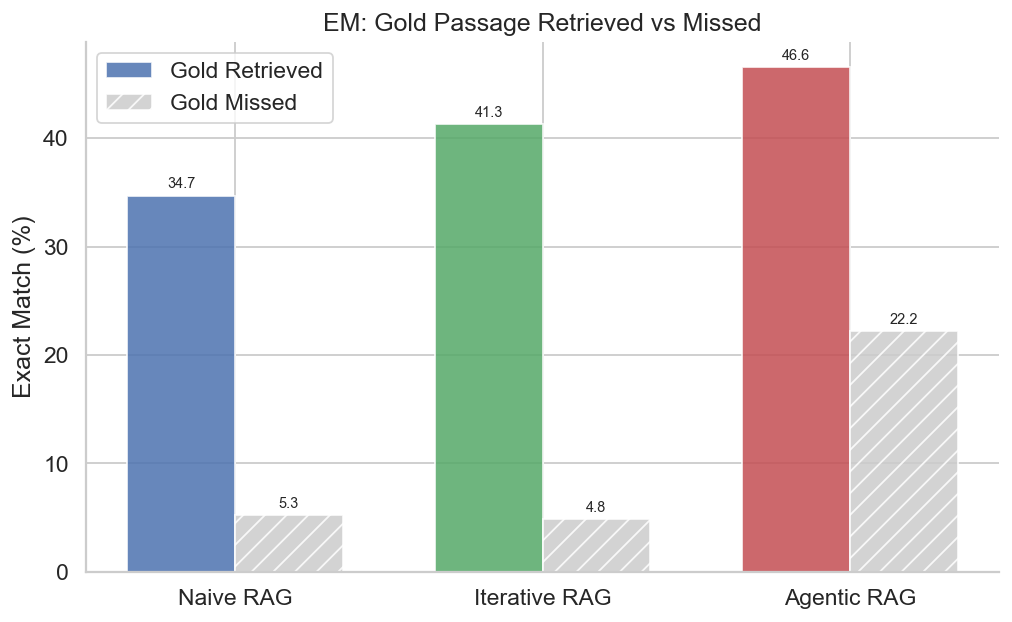

Saved → results/figures/retrieval_impact.png


In [6]:
# ── Figure 2a: EM split by retrieval success (all questions) ─────────────────
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(SYSTEMS))
width = 0.35

for j, (group, label, hatch) in enumerate([
    (1, "Gold Retrieved", ""),
    (0, "Gold Missed",    "//"),
]):
    vals = []
    for s in SYSTEMS:
        sub = dfs[s][dfs[s].retrieval_success == group]
        vals.append(sub["em"].mean() * 100 if len(sub) > 0 else 0)
    bars = ax.bar(x + (j - 0.5) * width, vals, width,
                  label=label, alpha=0.85, hatch=hatch,
                  color=[PALETTE[s] for s in SYSTEMS] if group == 1
                        else ["#cccccc"] * len(SYSTEMS))
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                f"{v:.1f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([LABELS[s] for s in SYSTEMS])
ax.set_ylabel("Exact Match (%)")
ax.set_title("EM: Gold Passage Retrieved vs Missed")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/retrieval_impact.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/figures/retrieval_impact.png")

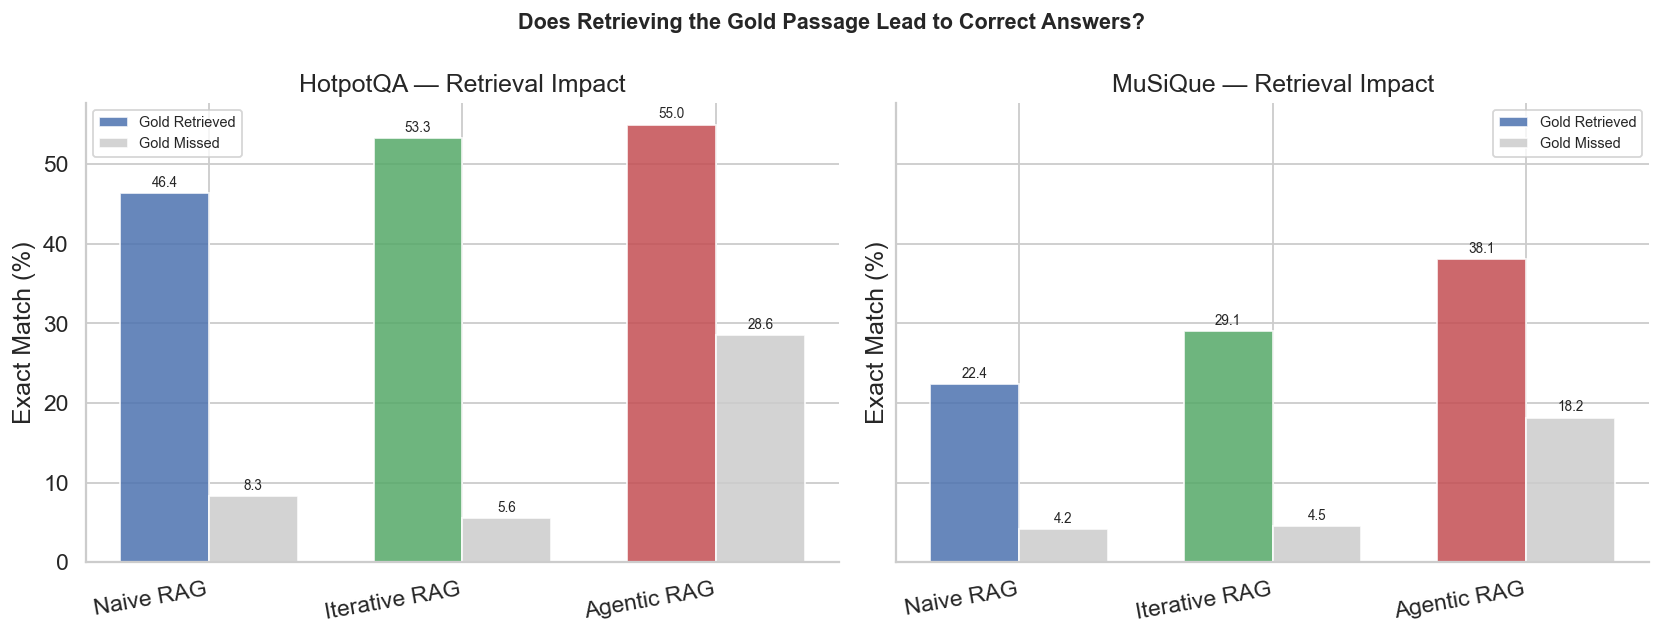

Saved → results/figures/retrieval_impact_by_dataset.png


In [7]:
# ── Figure 2b: same split, broken down by dataset ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, ds, ds_label in zip(axes, ["hotpotqa", "musique"],
                             ["HotpotQA", "MuSiQue"]):
    x = np.arange(len(SYSTEMS))
    width = 0.35
    for j, (group, label, color_fn) in enumerate([
        (1, "Gold Retrieved", lambda s: PALETTE[s]),
        (0, "Gold Missed",    lambda s: "#cccccc"),
    ]):
        vals = []
        for s in SYSTEMS:
            sub = dfs[s][(dfs[s].retrieval_success == group) &
                         (dfs[s].dataset == ds)]
            vals.append(sub["em"].mean() * 100 if len(sub) > 0 else 0)
        bars = ax.bar(x + (j - 0.5) * width, vals, width,
                      label=label, alpha=0.85,
                      color=[color_fn(s) for s in SYSTEMS])
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                    f"{v:.1f}", ha="center", va="bottom", fontsize=7.5)

    ax.set_xticks(x)
    ax.set_xticklabels([LABELS[s] for s in SYSTEMS], rotation=10, ha="right")
    ax.set_ylabel("Exact Match (%)")
    ax.set_title(f"{ds_label} — Retrieval Impact")
    ax.legend(fontsize=8)

fig.suptitle("Does Retrieving the Gold Passage Lead to Correct Answers?",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/figures/retrieval_impact_by_dataset.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/figures/retrieval_impact_by_dataset.png")

In [8]:
# ── Upper-bound analysis: if ALL systems had perfect retrieval ────────────────
print("Upper-bound EM (only questions where gold WAS retrieved):")
print()
for s in SYSTEMS:
    overall  = dfs[s]["em"].mean() * 100
    hit_only = dfs[s][dfs[s].retrieval_success == 1]["em"].mean() * 100
    ceiling  = hit_only
    print(f"  {LABELS[s]:20s}  Overall EM: {overall:.1f}%  "
          f"| Gold-retrieved EM: {ceiling:.1f}%  "
          f"| Gap: +{ceiling-overall:.1f}pp")

Upper-bound EM (only questions where gold WAS retrieved):

  Naive RAG             Overall EM: 33.3%  | Gold-retrieved EM: 34.7%  | Gap: +1.4pp
  Iterative RAG         Overall EM: 40.2%  | Gold-retrieved EM: 41.3%  | Gap: +1.1pp
  Agentic RAG           Overall EM: 46.4%  | Gold-retrieved EM: 46.6%  | Gap: +0.2pp
